**Worksheet2**

**Saroj Pandey**

**2406782**

In [30]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This functions implements basic AND operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1 nd array): An array of binary values.
    X2 (1 nd array): An array of binary values.
    Output:
    state_neuron(1D-list): An state of neuron 1 Or 0 for the particular inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for x1, x2 in zip(X1, X2):
        s = x1 + x2
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [31]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [32]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for x1, x2 in zip(X1, X2):
        s = x1 + x2
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [33]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

result_or = MCP_Neurons_OR(X1, X2, T)

print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**Question-1: Limitations of MCP Neurons**

The main limitations of MCP neurons are:

1.Binary inputs and outputs only
MCP neuron works only with 0 and 1 values.

2.No learning ability
It cannot learn from data or update itself.

3.Fixed threshold
The threshold is predefined and does not change automatically.

4.Can solve only simple logical problems
It can solve basic gates like AND, OR, and NOT only.

5.Cannot solve non-linearly separable problems
It cannot solve problems like XOR using a single MCP neuron.

6.No weighted learning mechanism
It does not adjust weights like modern neural networks.

7.Very simple model
It is much simpler than real biological neurons and modern artificial neurons.

Question-2: Can XOR be solved using MCP Neuron?

Because XOR is a non-linearly separable problem.
This means the inputs and outputs of XOR cannot be separated by a single straight line or single threshold rule.

| X1 | X2 | XOR Output |
| -- | -- | ---------- |
| 0  | 0  | 0          |
| 0  | 1  | 1          |
| 1  | 0  | 1          |
| 1  | 1  | 0          |

A single MCP neuron uses only:

sum of inputs

threshold

simple decision rule

So it cannot produce XOR output correctly for all cases.

Can we devise if-else rules?

Yes, manually we can write if-else rules for XOR, such as:

if X1 != X2:

    y = 1
else:

    y = 0


But this is not the same as solving XOR using a single MCP neuron.

Conclusion:

1. Single MCP neuron: cannot solve XOR

2. Using manual if-else logic: yes, XOR output can be generated

3. Using multiple neurons/layers: XOR can be solved

A single MCP neuron is limited to simple linearly separable problems, so it cannot solve XOR. XOR can only be handled by using manual logic or multiple neurons.




In [34]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Question 1: What does the shape of X represent?

The shape of X represents the size of the feature matrix.


Rows = number of samples/images in the dataset


Columns = number of features/pixels in each image

Since MNIST images are 28 × 28, each image has:

28×28=784

So if X.shape = (m, 784), it means:

m = total number of images

784 = total number of pixels for each image

Question 2: What does the shape of y represent?

The shape of y represents the size of the label vector.

It contains the class label for each image

each value is the output label, here 0 or 1

So if y.shape = (m,), it means:

there are m labels

one label for each image in X

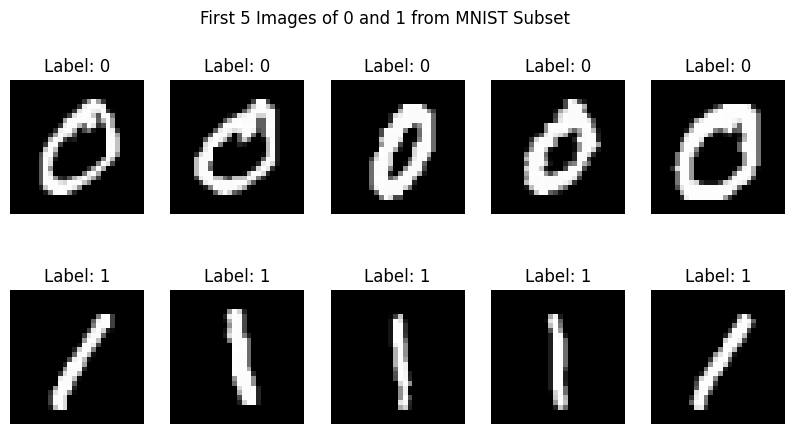

In [35]:
import matplotlib.pyplot as plt

# Separate images for label 0 and label 1
images_0 = X[y == 0]   # Get all images with label 0
images_1 = X[y == 1]   # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

In [36]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Question 3: What does the weights array represent in this context?

The weights array represents the importance of each input feature (pixel) in the model.

In the MNIST dataset, each image has 784 pixels, so the weights array contains one weight for each pixel. These weights help the model decide how much each pixel contributes to predicting whether the image is a 0 or a 1.

So, in simple words:

1. each weight is linked to one pixel

2. it tells how important that pixel is for classification

3. during training, the model updates these weights to improve prediction

Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?

We initialize the weights to zero because it is a simple and easy starting point.

At the beginning, the model has not learned anything yet, so all features are given equal importance. During training, the weights are updated step by step based on the error.

Effect on training:

1. for logistic regression, starting with zeros is usually okay

2. the model can still learn and update the weights properly

3. but if all weights start at zero, the model begins with no preference for any feature

Important note:
1. in simple linear or logistic regression, zero initialization is acceptable
2. in multi-layer neural networks, zero initialization is not good because all neurons may learn the same thing

In [37]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias

    ##### Your Code Here ############
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

In [38]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """

    for epoch in range(epochs):
        for i in range(X.shape[0]):
            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            # Step activation
            y_pred = 1 if linear_output >= 0 else 0

            # Perceptron update rule
            error = y[i] - y_pred
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

    # Final prediction after training
    y_pred_all = np.where(np.dot(X, weights) + bias >= 0, 1, 0)

    # Accuracy
    accuracy = np.sum(y_pred_all == y)

    return weights, bias, accuracy

In [39]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0

# Train perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100)

print("Updated weights:", weights)
print("Updated bias:", bias)
print("Total correct predictions:", accuracy)

Updated weights: [   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     4.5   73.5
   17.7    0.    30.6   71.7   17.1    0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     5.4    4.8    0.     0.    37.4   66.8   57.2   49.4
  101.8  113.8   43.3   14.7   22.2   10.1    0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.    -5.    -8.
   42.6   66.7   16.1    9.9   57.6   99.5  123.2  100.8   33.9   67.9
  -29.9  114.4  110.6   65.6   21.4    8.     0.     0.     0.     0.


Question 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

This line calculates the weighted sum of the input features for one training sample.

X[i] = the current input sample
weights = importance of each feature
bias = extra value added to shift the decision boundary

So this line helps the perceptron decide whether the sample belongs to class 0 or class 1.

In simple words, it computes the score used for prediction.

Question 6: What happens when the prediction is wrong? How are the weights and bias updated?

When the prediction is wrong, the perceptron adjusts its weights and bias to reduce future errors.

First, error is calculated:

𝑒
𝑟
𝑟
𝑜
𝑟
=
𝑦
[
𝑖
]
−
𝑦
_
𝑝
𝑟
𝑒
𝑑
error=y[i]−y_pred

Then weights and bias are updated as:

𝑤
𝑒
𝑖
𝑔
ℎ
𝑡
𝑠
=
𝑤
𝑒
𝑖
𝑔
ℎ
𝑡
𝑠
+
𝑙
𝑒
𝑎
𝑟
𝑛
𝑖
𝑛
𝑔
_
𝑟
𝑎
𝑡
𝑒
×
𝑒
𝑟
𝑟
𝑜
𝑟
×
𝑋
[
𝑖
]
weights=weights+learning_rate×error×X[i]
𝑏
𝑖
𝑎
𝑠
=
𝑏
𝑖
𝑎
𝑠
+
𝑙
𝑒
𝑎
𝑟
𝑛
𝑖
𝑛
𝑔
_
𝑟
𝑎
𝑡
𝑒
×
𝑒
𝑟
𝑟
𝑜
𝑟
bias=bias+learning_rate×error
Meaning:
if prediction is too low, weights and bias increase
if prediction is too high, weights and bias decrease

This helps the model learn from mistakes.

Question 7: Why is the final accuracy important, and what do you expect it to be?

Final accuracy is important because it shows how well the perceptron learned from the training data.

It tells us how many samples were classified correctly after training.

Why it matters:

1. higher accuracy means better performance
2. it helps check whether the model learned the pattern correctly
What to expect:

Since this task is classifying only digits 0 and 1, which are easy to separate, the final accuracy is expected to be very high, often close to 100% on training data.

In [40]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  12665


In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question 8: What does misclassified_idx store, and how is it used in this code?

misclassified_idx stores the indices (positions) of the images that were predicted wrongly by the model.

This line finds them:

misclassified_idx = np.where(y_pred != y)[0]

Meaning:
1. y_pred = predicted labels
2. y = true labels
3. y_pred != y checks where prediction is wrong
4. np.where(...)[0] gives the index numbers of those wrong predictions

How it is used:

These indices are used to:

1. select the wrongly classified images from X
2. display them using imshow()
3. compare predicted label and true label

So it helps us see which images the model got wrong.

Question 9: How do you interpret the result if the output is “All images were correctly classified!”?

This means the perceptron predicted every image correctly in the dataset being tested.

So:

1. there are no misclassified images
2. model accuracy is 100%
3. the perceptron has learned the data very well
In this case:

Since the dataset contains only digits 0 and 1, this result is possible because these two classes are usually easier to separate.

Simple interpretation:

The model performed perfectly on that dataset.

In [42]:
df_3_5 = pd.read_csv("/content/mnist_3_and_5.csv")   # change path if needed

X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2741, 784)
Shape of y: (2741,)


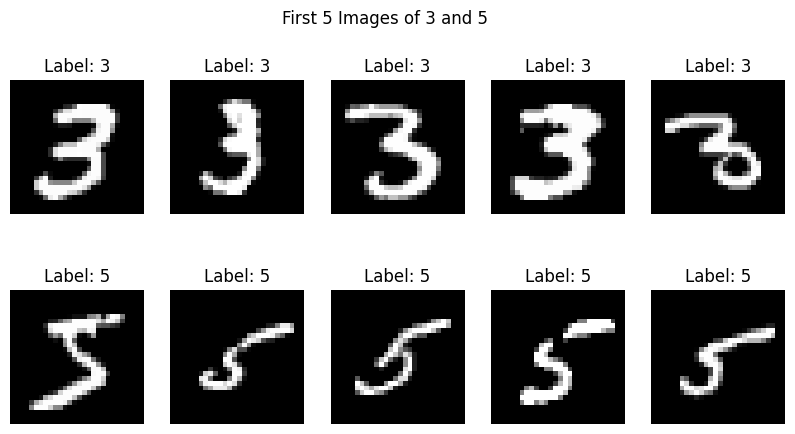

In [43]:
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5")
plt.show()

In [44]:
y_binary = np.where(y == 3, 0, 1)

In [45]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

weights, bias, accuracy = train_perceptron(X, y_binary, weights, bias, learning_rate, epochs)

print("Training Accuracy:", accuracy)

predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y_binary)
print(f"Final Accuracy: {final_accuracy:.4f}")

Training Accuracy: 2705
Final Accuracy: 0.9869


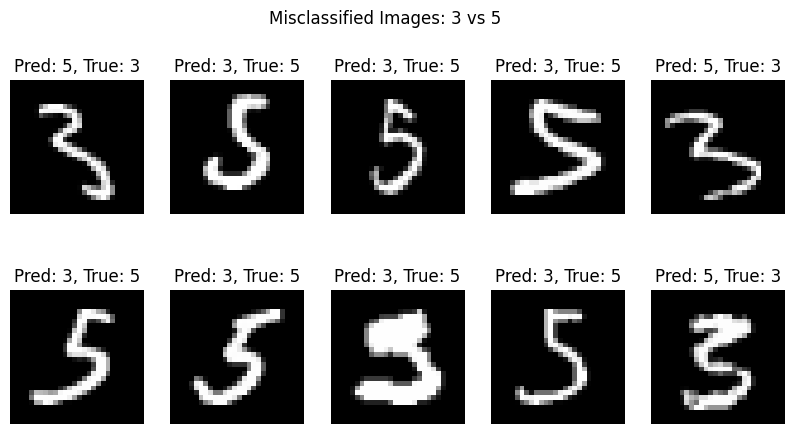

In [46]:
misclassified_idx = np.where(y_pred != y_binary)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")

        pred_label = 3 if y_pred[idx] == 0 else 5
        true_label = 3 if y_binary[idx] == 0 else 5

        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")

    plt.suptitle("Misclassified Images: 3 vs 5")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:

In this exercise, the Perceptron learning algorithm was implemented for binary classification of MNIST digits 3 and 5. The model was trained by updating weights and bias based on prediction errors. After training, the perceptron was able to classify most images correctly, though some images may still be misclassified because digits 3 and 5 can look similar in handwriting. The misclassified images help us understand where the model makes mistakes. Overall, the perceptron works for simple binary classification, but its performance may be limited when the classes are not perfectly linearly separable.